# Curve Curation Walkthrough: Flood x Solar

This is the **start-here curation notebook** for the `flood_solar` damage-curve cell.

The companion notebook, `01_runtime_curve_walkthrough.ipynb`, starts from the finished JSON artifact and asks: **how do I evaluate this flood damage code?**

This notebook starts earlier and asks: **how did we curate the flood x solar curve package?**

It follows the proof trail:

```text
source evidence
  -> source interpretation
  -> failure-unit coverage
  -> x-axis decision
  -> curve-form decision
  -> piecewise/state ordinates
  -> selectors, conditioners, exposure variables
  -> value linkage
  -> capability gates and open seams
```

The formal source of truth is still the cell package under `docs/`. This notebook is the teaching / review / update companion.


## How To Read The Notebook

This notebook intentionally includes two kinds of content:

1. **Current v1.0 model behavior**: what the artifact and dossier actually say today.
2. **Review notes / future placeholders**: comments that name where the curation process or future runtime code should improve.

The placeholders are not bugs. They are a way to keep future work visible inside the learning artifact.

> **Review convention:** when a section has a `Future update placeholder`, it is a good candidate for a future curation/code task, not something the current runtime notebook should silently solve.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "docs/damage_curves").exists():
            return candidate
    raise RuntimeError("Could not find damage_modeling repo root.")


REPO_ROOT = find_repo_root(Path.cwd())
CELL_DIR = REPO_ROOT / "docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/flood_solar/current"
ARTIFACT_PATH = CELL_DIR / "flood_solar__model_v1_0__docs_r3__curve_artifact.json"
DOSSIER_PATH = CELL_DIR / "flood_solar_curve_derivation_dossier_v1_0.md"
METADATA_SPEC_PATH = CELL_DIR / "flood_solar_damage_code_metadata_spec_v1_0.md"
OUTPUT_DIR = REPO_ROOT / "notebooks/flood/solar/outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with ARTIFACT_PATH.open("r", encoding="utf-8") as f:
    artifact = json.load(f)

assert artifact["canonical_runtime_artifact"] is True

print(f"repo root : {REPO_ROOT}")
print(f"artifact  : {ARTIFACT_PATH.relative_to(REPO_ROOT)}")
print(f"dossier   : {DOSSIER_PATH.relative_to(REPO_ROOT)}")
print(f"outputs   : {OUTPUT_DIR.relative_to(REPO_ROOT)}")


repo root : /Users/divy/code/work/infrasure_git_codes/damage_modeling
artifact  : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/flood_solar/current/flood_solar__model_v1_0__docs_r3__curve_artifact.json
dossier   : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/flood_solar/current/flood_solar_curve_derivation_dossier_v1_0.md
outputs   : notebooks/flood/solar/outputs


## 1. Why Flood Needs The Full Architecture

The key curation decision is that flood x solar cannot be represented honestly by one plant-level flood curve.

One flood event can interact with:

- inverter cabinets;
- switchgear;
- transformer controls and terminals;
- combiner / DC protection boxes;
- SCADA and monitoring cabinets;
- cable/conduit pathways;
- module lower edges;
- foundations and scour.

Each has a different exposed datum, value bucket, and physical failure mechanism.

So the cell is **multi-failure-unit** from day one.


,field,value
0,cell_id,flood_solar
1,damage_code_id,FLOOD_SOLAR_ELECTRICAL_INUNDATION_V1
2,semantic_model_version,model v1.0
3,documentation_revision,docs r3
4,canonical_runtime_artifact,True


,id,subsystem,component,treatment,axis,y_axis,f_kind
0,FS_INV,INVERTER_SYSTEM,INVERTER,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
1,FS_SWG,SUBSTATION,SWITCHGEAR,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
2,FS_XFMR,SUBSTATION,TRANSFORMER_MAIN,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
3,FS_COMB,INVERTER_SYSTEM,COMBINER_BOX + DC_PROTECTION,primary_secondary,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
4,FS_SCADA,SCADA,MONITORING_SYSTEM,secondary,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
5,FS_CABLE,ELECTRICAL_COLLECTION,CABLE_AC + CABLE_DC,conditional_secondary,depth_pathway_termination_exposure,failure_unit_damage_ratio,site_geometry
6,FS_PVMOD,PV_ARRAY,PV_MODULE,conditional_secondary,depth_above_module_lower_edge_m,failure_unit_damage_ratio,site_geometry
7,FS_FOUND,FOUNDATION,FOUNDATION_BASE,conditional_secondary,flow_velocity_or_scour_proxy,failure_unit_damage_ratio,site_geometry


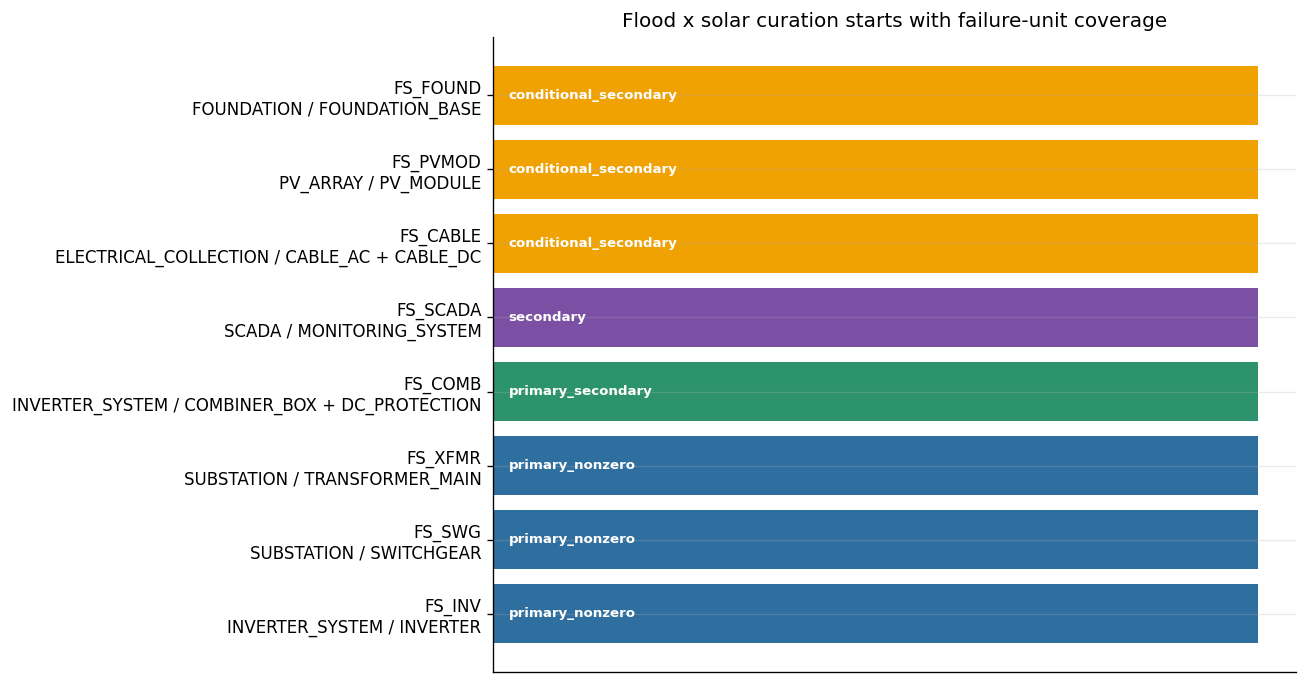

In [2]:
identity = pd.DataFrame([
    {"field": "cell_id", "value": artifact["cell_id"]},
    {"field": "damage_code_id", "value": artifact["damage_code_id"]},
    {"field": "semantic_model_version", "value": artifact["semantic_damage_model_version"]},
    {"field": "documentation_revision", "value": artifact["documentation_revision"]},
    {"field": "canonical_runtime_artifact", "value": artifact["canonical_runtime_artifact"]},
])
display(identity)

failure_units = pd.DataFrame(artifact["failure_units"])
display(failure_units)

fig, ax = plt.subplots(figsize=(11, 5.8))
plot_df = failure_units.copy()
plot_df["label"] = plot_df["id"] + "\n" + plot_df["subsystem"] + " / " + plot_df["component"]
treatment_colors = {
    "primary_nonzero": "#2f6f9f",
    "primary_secondary": "#2d936c",
    "secondary": "#7b4fa3",
    "conditional_secondary": "#f0a202",
}
ax.barh(plot_df["label"], [1] * len(plot_df), color=[treatment_colors.get(t, "#999") for t in plot_df["treatment"]])
ax.set_title("Flood x solar curation starts with failure-unit coverage")
ax.set_xticks([])
for y, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(0.02, y, row["treatment"], va="center", ha="left", color="white", fontsize=8, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_failure_unit_coverage_curation.png", dpi=180, bbox_inches="tight")
plt.show()


> **Future update placeholder — coverage:** the current coverage is broad enough for a v1.0 solar flood cell, but a production implementation should connect each failure-unit to a formal value ledger row and an asset-substrate metadata requirement. In particular: electrical one-lines, conduit/pull-box routing, elevation survey fields, and foundation/geotech inputs should become explicit substrate fields, not ad hoc notebook assumptions.


## 2. Evidence Map: What Each Source Is Allowed To Support

The first curation discipline is not “find a source and copy a curve.” It is:

```text
source -> role -> limitation -> parameter/rule
```

A source can support a mechanism without supporting a final numeric curve. That distinction matters heavily for flood.


,evidence_id,source,supports,does_not_support,use_in_v1
0,DOE_FEMP_PV_FLOOD,DOE/FEMP solar PV flood mitigation guidance,"Solar-specific flood pathways: submersion, raised equipment, conduit paths, enclosure/drainage/scour mitigation",Final numeric depth-damage curves for each PV subsystem,mechanism + metadata requirements
1,NEMA_GD1_2019,NEMA water-damaged electrical equipment guidance,Replacement/reconditioning framing for water-exposed electrical equipment,Continuous flood-depth curves,steep electrical replacement logic after ingress
2,NEMA_ENCLOSURE_TYPES,NEMA enclosure type definitions,Rain/hosedown ratings vs temporary/prolonged submersion protection,Actual post-flood replacement cost by rating alone,selector/open-seam field for future curve variants
3,FEMA_P348,FEMA / Building America utility-system flood guide,Utility-system elevation/protection framing,PV-specific component DR ordinates,local-depth / freeboard axis bridge
4,USACE_HEC_FIA,HEC-FIA depth-percent damage relationships,Tabular depth-percent curve form and interpolation precedent,Solar-specific DR values,"piecewise/state curve form, not numeric solar values"
5,ANZGEO_2023_SCOUR_CONTEXT,Scour / hydraulic context source from evidence update,Scour mechanism relevance,Generic site-independent foundation DR curve,T4 foundation velocity/scour placeholder


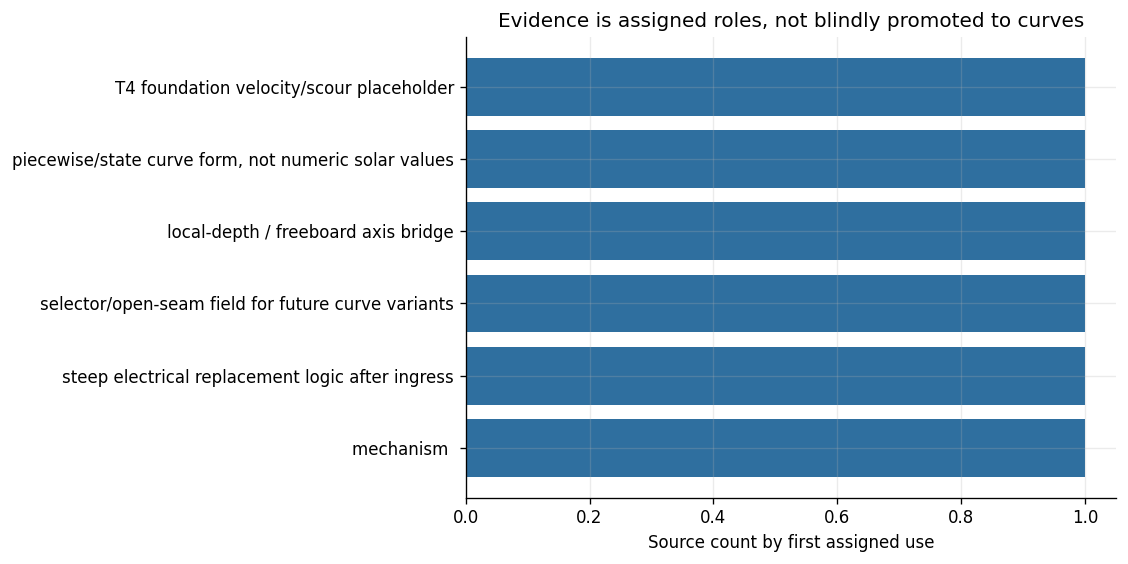

In [3]:
evidence_map = pd.DataFrame([
    {
        "evidence_id": "DOE_FEMP_PV_FLOOD",
        "source": "DOE/FEMP solar PV flood mitigation guidance",
        "supports": "Solar-specific flood pathways: submersion, raised equipment, conduit paths, enclosure/drainage/scour mitigation",
        "does_not_support": "Final numeric depth-damage curves for each PV subsystem",
        "use_in_v1": "mechanism + metadata requirements",
    },
    {
        "evidence_id": "NEMA_GD1_2019",
        "source": "NEMA water-damaged electrical equipment guidance",
        "supports": "Replacement/reconditioning framing for water-exposed electrical equipment",
        "does_not_support": "Continuous flood-depth curves",
        "use_in_v1": "steep electrical replacement logic after ingress",
    },
    {
        "evidence_id": "NEMA_ENCLOSURE_TYPES",
        "source": "NEMA enclosure type definitions",
        "supports": "Rain/hosedown ratings vs temporary/prolonged submersion protection",
        "does_not_support": "Actual post-flood replacement cost by rating alone",
        "use_in_v1": "selector/open-seam field for future curve variants",
    },
    {
        "evidence_id": "FEMA_P348",
        "source": "FEMA / Building America utility-system flood guide",
        "supports": "Utility-system elevation/protection framing",
        "does_not_support": "PV-specific component DR ordinates",
        "use_in_v1": "local-depth / freeboard axis bridge",
    },
    {
        "evidence_id": "USACE_HEC_FIA",
        "source": "HEC-FIA depth-percent damage relationships",
        "supports": "Tabular depth-percent curve form and interpolation precedent",
        "does_not_support": "Solar-specific DR values",
        "use_in_v1": "piecewise/state curve form, not numeric solar values",
    },
    {
        "evidence_id": "ANZGEO_2023_SCOUR_CONTEXT",
        "source": "Scour / hydraulic context source from evidence update",
        "supports": "Scour mechanism relevance",
        "does_not_support": "Generic site-independent foundation DR curve",
        "use_in_v1": "T4 foundation velocity/scour placeholder",
    },
])
display(evidence_map)

source_role_counts = evidence_map["use_in_v1"].str.extract(r"([^+;]+)")[0].value_counts()
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(source_role_counts.index, source_role_counts.values, color="#2f6f9f")
ax.set_title("Evidence is assigned roles, not blindly promoted to curves")
ax.set_xlabel("Source count by first assigned use")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_evidence_role_summary.png", dpi=180, bbox_inches="tight")
plt.show()


> **Future update placeholder — source cards:** the dossier has source links and role notes. A stronger production curation system should make source cards machine-readable, so the runtime artifact can show not only `source_ids` but also source type, access path, extracted fact, limitation, and exact parameter/rule supported.


## 3. X-Axis Decision: Reject Plant-Level Depth, Use Local Component Exposure

Rejected shortcut:

```text
site flood depth -> whole plant DR
```

Accepted v1.0 axis bridge for depth-driven units:

```text
h_i = max(0, WSE - z_i_crit)
```

Where:

- `WSE` is water surface elevation;
- `z_i_crit` is the vulnerable datum for component `i`;
- `h_i` is local water depth above that component datum.

This is the central spatial/elevation math in the flood damage code.


,id,input_field_preferred,fallback_input_field,internal_axis,formula,unit,valid_range,extrapolation_policy
0,FLOOD_LOCAL_DEPTH_COMPONENT_DATUM,water_surface_elevation_m,site_flood_depth_m,local_depth_above_component_datum_m,"h_i = max(0, WSE - z_i_crit)",m,"[0, 2.0]",clamp_or_warn


,candidate_axis,decision,why
0,site_depth_m -> whole plant DR,rejected,"hides equipment elevations, conduit paths, and distinct mechanisms"
1,depth x duration 2-D surface,deferred,"duration/salinity/contamination matter, but public evidence is not enough for v1 per failure-unit 2-D curves"
2,local depth above component datum,accepted for electrical/module depth pathways,freeboard and critical datum directly control water-entry exposure
3,flow velocity / scour proxy,accepted as placeholder for foundation/civil,"foundation/civil failure is hydraulic/geotech, not cabinet ingress"


,failure_unit_id,z_i_crit,meaning,local_depth_h_i
0,FS_CABLE,100.35,pull-box / conduit pathway,0.65
1,FS_COMB,100.55,combiner/DC enclosure,0.45
2,FS_XFMR,100.65,transformer controls / terminals,0.35
3,FS_INV,100.72,inverter cabinet,0.28
4,FS_SWG,100.84,switchgear cabinet,0.16
5,FS_SCADA,100.92,SCADA cabinet,0.08
6,FS_PVMOD,101.10,module lower edge,0.00


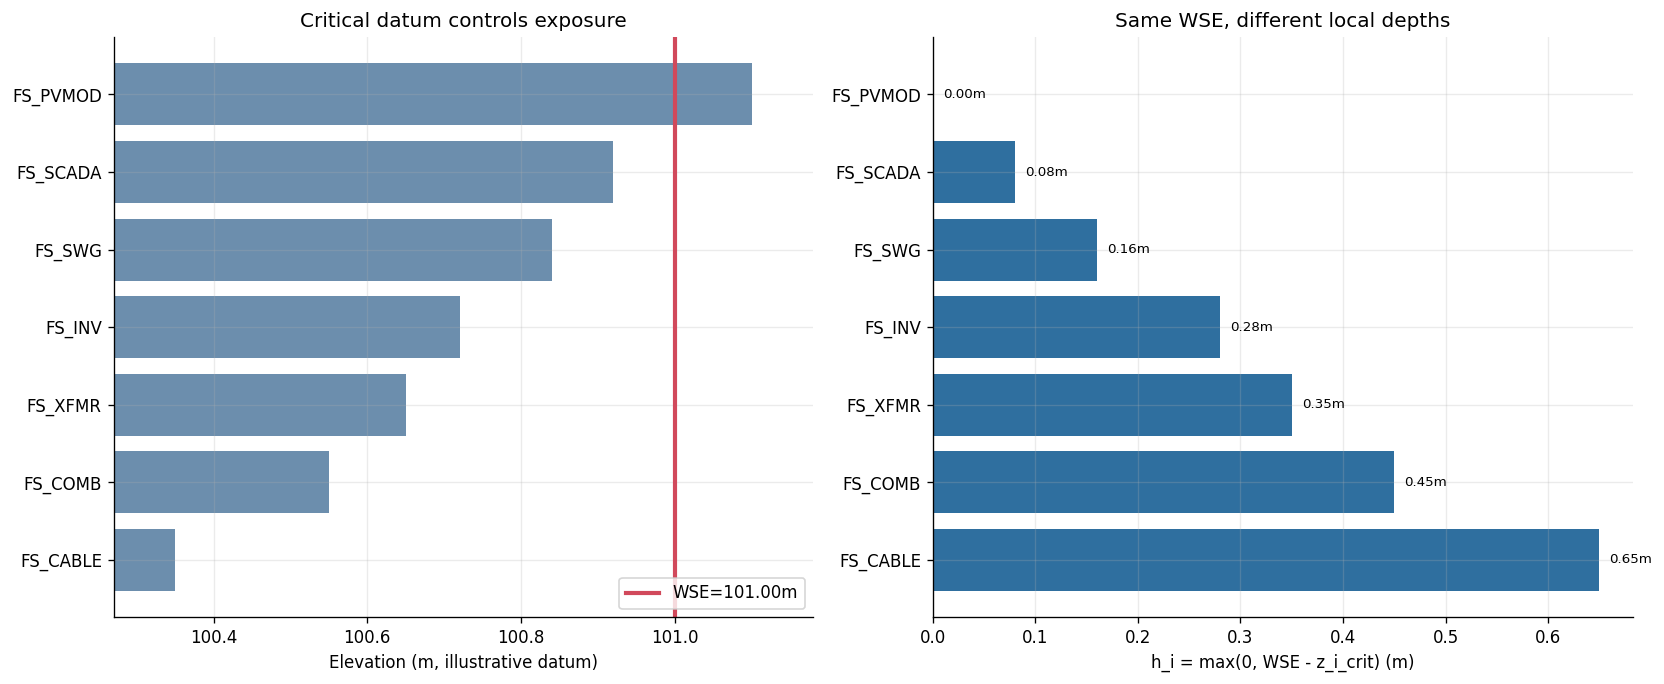

In [4]:
hazard_axis = pd.DataFrame([artifact["hazard_axis"]])
display(hazard_axis)

axis_decisions = pd.DataFrame([
    {"candidate_axis": "site_depth_m -> whole plant DR", "decision": "rejected", "why": "hides equipment elevations, conduit paths, and distinct mechanisms"},
    {"candidate_axis": "depth x duration 2-D surface", "decision": "deferred", "why": "duration/salinity/contamination matter, but public evidence is not enough for v1 per failure-unit 2-D curves"},
    {"candidate_axis": "local depth above component datum", "decision": "accepted for electrical/module depth pathways", "why": "freeboard and critical datum directly control water-entry exposure"},
    {"candidate_axis": "flow velocity / scour proxy", "decision": "accepted as placeholder for foundation/civil", "why": "foundation/civil failure is hydraulic/geotech, not cabinet ingress"},
])
display(axis_decisions)

WSE = 101.00
example_elevations = pd.DataFrame([
    {"failure_unit_id": "FS_CABLE", "z_i_crit": 100.35, "meaning": "pull-box / conduit pathway"},
    {"failure_unit_id": "FS_COMB", "z_i_crit": 100.55, "meaning": "combiner/DC enclosure"},
    {"failure_unit_id": "FS_XFMR", "z_i_crit": 100.65, "meaning": "transformer controls / terminals"},
    {"failure_unit_id": "FS_INV", "z_i_crit": 100.72, "meaning": "inverter cabinet"},
    {"failure_unit_id": "FS_SWG", "z_i_crit": 100.84, "meaning": "switchgear cabinet"},
    {"failure_unit_id": "FS_SCADA", "z_i_crit": 100.92, "meaning": "SCADA cabinet"},
    {"failure_unit_id": "FS_PVMOD", "z_i_crit": 101.10, "meaning": "module lower edge"},
])
example_elevations["local_depth_h_i"] = np.maximum(0.0, WSE - example_elevations["z_i_crit"])
display(example_elevations)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
ax = axes[0]
plot_df = example_elevations.sort_values("z_i_crit")
ax.barh(plot_df["failure_unit_id"], plot_df["z_i_crit"], color="#6c8ead")
ax.axvline(WSE, color="#d1495b", lw=2.5, label=f"WSE={WSE:.2f}m")
ax.set_xlim(plot_df["z_i_crit"].min() - 0.08, max(plot_df["z_i_crit"].max(), WSE) + 0.08)
ax.set_title("Critical datum controls exposure")
ax.set_xlabel("Elevation (m, illustrative datum)")
ax.legend(loc="lower right")

ax = axes[1]
ax.barh(plot_df["failure_unit_id"], plot_df["local_depth_h_i"], color="#2f6f9f")
ax.set_title("Same WSE, different local depths")
ax.set_xlabel("h_i = max(0, WSE - z_i_crit) (m)")
for y, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["local_depth_h_i"] + 0.01, y, f"{row['local_depth_h_i']:.2f}m", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_local_depth_axis_decision.png", dpi=180, bbox_inches="tight")
plt.show()


> **Future update placeholder — axis bridge code:** the current artifact names the bridge `h_i=max(0,WSE-z_i_crit)`. Production code should centralize this as a reusable helper with explicit vertical datum checks. If WSE and component elevations are not in the same datum, the code should fail closed rather than silently compute local depths.


## 4. Curve-Form Decision: Why Piecewise/State Curves, Not Logistic

Hail module breakage used a logistic curve because breakage probability transitions smoothly with hail size.

Flood electrical damage is different. It often follows water-entry states:

```text
dry / below critical datum
  -> water reaches enclosure path
  -> partial ingress / contamination
  -> critical components wet
  -> full submersion or replacement likely
```

So v1.0 uses piecewise-linear depth-percent/state curves.


In [5]:
form_alternatives = pd.DataFrame([
    {"curve_form": "step function", "decision": "rejected", "reason": "too brittle; real sites have uncertainty in datum, sealing, contamination, and construction"},
    {"curve_form": "logistic", "decision": "rejected as default", "reason": "suggests smooth fragility; flood equipment damage is threshold/state-like"},
    {"curve_form": "piecewise-linear depth-percent", "decision": "accepted", "reason": "auditable ordinates; aligns with depth-damage precedent and waterline states"},
    {"curve_form": "discrete damage states only", "decision": "compatible/deferred", "reason": "artifact can evolve to state table emits; current runtime interpolates deterministic ordinates"},
    {"curve_form": "2-D depth x duration/salinity", "decision": "deferred", "reason": "mechanism matters, but public evidence does not support per-unit 2-D surfaces yet"},
])
display(form_alternatives)


,curve_form,decision,reason
0,step function,rejected,"too brittle; real sites have uncertainty in datum, sealing, contamination, and construction"
1,logistic,rejected as default,suggests smooth fragility; flood equipment damage is threshold/state-like
2,piecewise-linear depth-percent,accepted,auditable ordinates; aligns with depth-damage precedent and waterline states
3,discrete damage states only,compatible/deferred,artifact can evolve to state table emits; current runtime interpolates deterministic ordinates
4,2-D depth x duration/salinity,deferred,"mechanism matters, but public evidence does not support per-unit 2-D surfaces yet"


> **Future update placeholder — emit shape:** flood is the natural place to test a richer `discrete_state_table` emit. The current artifact stores deterministic piecewise curves, not an uncertainty distribution. A future update should decide whether flood remains scalar/interpolated or emits explicit state probabilities when evidence supports them.


## 5. Base Curve Ordinates: What Is Derived Versus Assumed

Source-anchored decisions:

- use local water depth rather than plant-level flood depth;
- treat submerged electrical/PV components as high-loss or potential total-loss;
- distinguish transformer salvage/evaluation from switchgear/power electronics;
- use tabular/piecewise curves rather than a generic smooth curve.

Engineering assumptions in v1.0:

- exact DR percentages at intermediate depths;
- foundation/scour numeric velocity curve;
- conduit water-path numeric effect;
- duration, salinity, contamination effects.

The runtime artifact carries these as tiered parameters and open seams.


,curve_id,failure_unit_id,curve_form,x_axis,n_points,max_DR
0,FS_INV,FS_INV,piecewise_linear,local_depth_above_component_datum_m,9,1.00
1,FS_SWG,FS_SWG,piecewise_linear,local_depth_above_component_datum_m,9,1.00
2,FS_XFMR,FS_XFMR,piecewise_linear,local_depth_above_component_datum_m,9,1.00
3,FS_COMB,FS_COMB,piecewise_linear,local_depth_above_component_datum_m,9,1.00
4,FS_SCADA,FS_SCADA,piecewise_linear,local_depth_above_component_datum_m,9,1.00
5,FS_CABLE,FS_CABLE,piecewise_linear,depth_pathway_termination_exposure,9,0.65
6,FS_PVMOD,FS_PVMOD,piecewise_linear,depth_above_module_lower_edge_m,9,1.00
7,FS_FOUND,FS_FOUND,piecewise_linear,flow_velocity_mps_or_scour_proxy,7,1.00


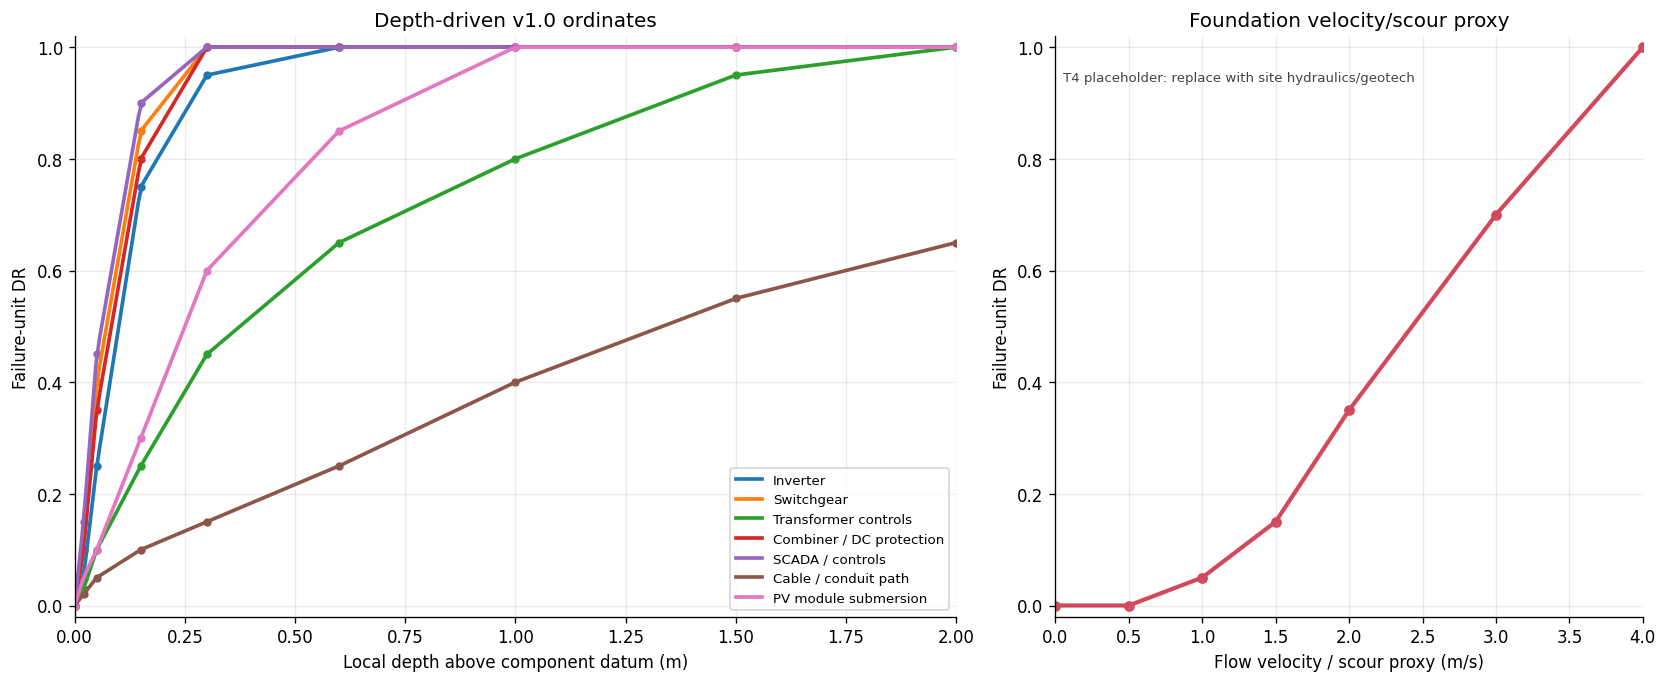

In [6]:
curve_records = artifact["curve_records"]
curve_by_id = {rec["curve_id"]: rec for rec in curve_records}
curve_by_fu = {rec["failure_unit_id"]: rec for rec in curve_records}

curve_summary = pd.DataFrame([
    {
        "curve_id": rec["curve_id"],
        "failure_unit_id": rec["failure_unit_id"],
        "curve_form": rec["curve_form"],
        "x_axis": rec["x_axis"],
        "n_points": len(rec["parameters"]["points"]),
        "max_DR": max(p[1] for p in rec["parameters"]["points"]),
    }
    for rec in curve_records
])
display(curve_summary)


def piecewise_dr(x, points):
    pts = np.asarray(points, dtype=float)
    return np.interp(np.asarray(x, dtype=float), pts[:, 0], pts[:, 1], left=pts[0, 1], right=pts[-1, 1])

labels = {
    "FS_INV": "Inverter",
    "FS_SWG": "Switchgear",
    "FS_XFMR": "Transformer controls",
    "FS_COMB": "Combiner / DC protection",
    "FS_SCADA": "SCADA / controls",
    "FS_CABLE": "Cable / conduit path",
    "FS_PVMOD": "PV module submersion",
    "FS_FOUND": "Foundation scour proxy",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.5, 1.0]})
ax = axes[0]
for rec in curve_records:
    if "flow_velocity" in rec["x_axis"] or "scour" in rec["x_axis"]:
        continue
    pts = np.asarray(rec["parameters"]["points"], dtype=float)
    x = np.linspace(pts[:, 0].min(), pts[:, 0].max(), 250)
    ax.plot(x, piecewise_dr(x, pts), lw=2.2, label=labels.get(rec["failure_unit_id"], rec["failure_unit_id"]))
    ax.scatter(pts[:, 0], pts[:, 1], s=16)
ax.set_title("Depth-driven v1.0 ordinates")
ax.set_xlabel("Local depth above component datum (m)")
ax.set_ylabel("Failure-unit DR")
ax.set_xlim(0, 2.0)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
rec = curve_by_fu["FS_FOUND"]
pts = np.asarray(rec["parameters"]["points"], dtype=float)
x = np.linspace(pts[:, 0].min(), pts[:, 0].max(), 250)
ax.plot(x, piecewise_dr(x, pts), lw=2.5, color="#d1495b")
ax.scatter(pts[:, 0], pts[:, 1], s=30, color="#d1495b")
ax.set_title("Foundation velocity/scour proxy")
ax.set_xlabel("Flow velocity / scour proxy (m/s)")
ax.set_ylabel("Failure-unit DR")
ax.set_xlim(0, 4.0)
ax.set_ylim(-0.02, 1.02)
ax.text(0.05, 0.94, "T4 placeholder: replace with site hydraulics/geotech", fontsize=8, color="#444")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_base_curve_ordinates.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Parameter Tiers: What We Trust, And How Much

The artifact’s tier table is the honesty mechanism.

- The **local-depth transform** is T2: component elevation/freeboard is source-supported.
- The **electrical depth-damage ordinates** are mostly T3: mechanisms are source-supported, exact percentages are engineering parameterization.
- The **foundation/scour proxy** is T4: site hydraulics/geotech dominate.


,parameter,curve_id,param_role,tier,source_ids,reasoning,update_trigger
0,depth_damage_points,FS_INV,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
1,depth_damage_points,FS_SWG,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
2,depth_damage_points,FS_XFMR,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
3,depth_damage_points,FS_COMB,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
4,depth_damage_points,FS_SCADA,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
5,depth_damage_points,FS_CABLE,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
6,depth_damage_points,FS_PVMOD,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
7,foundation_velocity_scour_points,FS_FOUND,open_seam_placeholder,T4_placeholder_or_expert_judgment,ANZGEO_2023_SCOUR_CONTEXT,Scour is site-geotechnical; generic velocity proxy is retained only as conditional placeholder.,hydraulic/geotechnical model or forensic scour dataset
8,local_depth_transform,all_depth_curves,axis_bridge,T2_public_lab_standard_or_physics,"DOE_FEMP_PV_FLOOD, FEMA_P348",Component freeboard/elevation controls local exposure.,none; replace only if cell axis changes


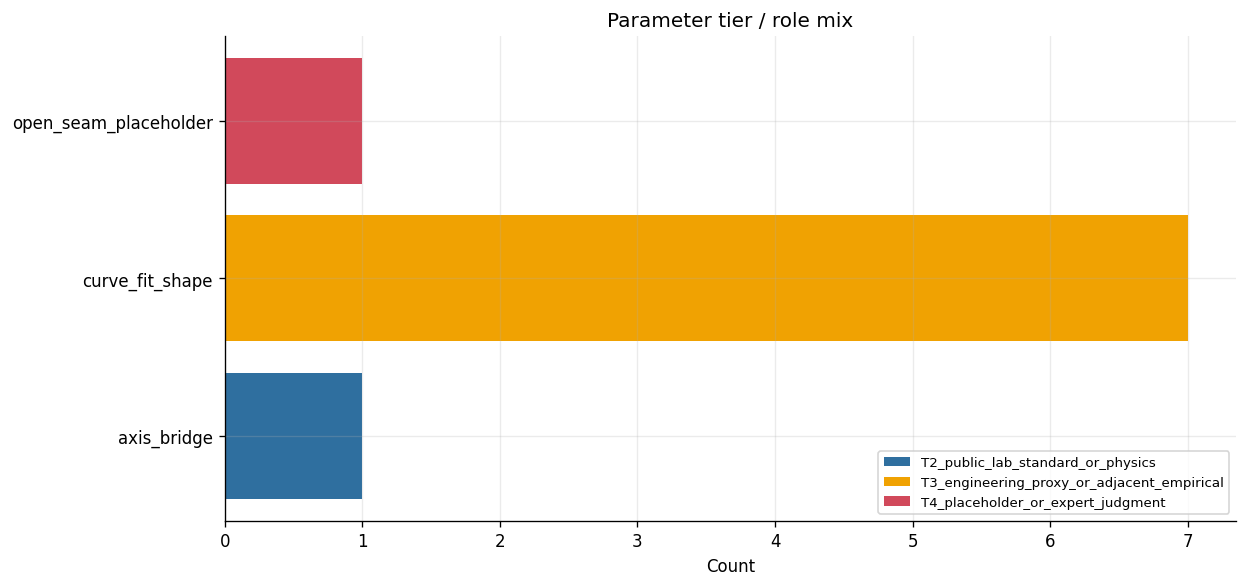

In [7]:
param_tiers = pd.DataFrame(artifact["parameter_tier_table"])
param_tiers["source_ids"] = param_tiers["source_ids"].apply(lambda xs: ", ".join(xs))
display(param_tiers[["parameter", "curve_id", "param_role", "tier", "source_ids", "reasoning", "update_trigger"]])

tier_order = ["T2_public_lab_standard_or_physics", "T3_engineering_proxy_or_adjacent_empirical", "T4_placeholder_or_expert_judgment"]
tier_counts = param_tiers.groupby(["tier", "param_role"]).size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(10.5, 5.0))
colors = {"T2_public_lab_standard_or_physics": "#2f6f9f", "T3_engineering_proxy_or_adjacent_empirical": "#f0a202", "T4_placeholder_or_expert_judgment": "#d1495b"}
for idx, row in tier_counts.iterrows():
    ax.barh(row["param_role"], row["count"], color=colors.get(row["tier"], "#999"), label=row["tier"] if row["tier"] not in ax.get_legend_handles_labels()[1] else None)
ax.set_title("Parameter tier / role mix")
ax.set_xlabel("Count")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_parameter_tier_role_mix.png", dpi=180, bbox_inches="tight")
plt.show()


> **Future update placeholder — assumptions register:** exact depth-damage percentages are currently engineering parameterization. A future curation notebook should read the workbook assumption register directly and show each ordinate family next to its assumption/update trigger. That would make the “why this percentage?” review path stronger.


## 7. Selectors, Conditioners, Exposure: Same Words, Flood-Specific Meaning

The architecture vocabulary is consistent across hazards, but the physical meaning changes.

For flood:

- **Selector**: fixed asset attribute, such as enclosure rating or transformer type.
- **Conditioner**: event-time/pathway state, such as conduit water path, energized state, duration, contamination.
- **Exposure geometry / axis bridge**: component critical elevation changes local depth.
- **Exposure multiplier**: fraction of the value bucket exposed to the flood swath.


In [8]:
display(Markdown("**Selector logic in artifact**"))
display(pd.DataFrame(artifact["selector_logic"]))

display(Markdown("**Conditioner / axis-bridge logic in artifact**"))
display(pd.DataFrame(artifact["conditioner_logic"]))

display(Markdown("**Exposure logic in artifact**"))
display(pd.DataFrame(artifact["exposure_logic"]))

role_examples = pd.DataFrame([
    {"situation": "Inverter pad raised by 0.5m", "category": "axis bridge / horizontal exposure shift", "correct_treatment": "reduce local depth h_i; do not change intrinsic curve"},
    {"situation": "Switchgear replaced by Type 6P submersible cabinet", "category": "selector / future curve variant", "correct_treatment": "select or build a different curve if evidence supports it"},
    {"situation": "Equipment energized during inundation", "category": "conditioner", "correct_treatment": "severity/flag adjustment; not primary x-axis in v1"},
    {"situation": "Only half inverter stations in flood swath", "category": "exposure multiplier", "correct_treatment": "scale value with fraction_value_exposed"},
    {"situation": "Flooded pull boxes drain through conduit to inverter", "category": "conditioner/open seam", "correct_treatment": "requires site design; no universal multiplier in v1"},
])
display(role_examples)


**Selector logic in artifact**

,field,aliases,required,effect,canonical
0,enclosure_rating,[equipment_ip_or_nema_rating],recommended,selects_curve_variant_or_flags_submersion_resistance,True
1,enclosure_rating_system,NaN,False,distinguishes NEMA versus IP rating basis,NaN
2,transformer_type,NaN,False,future transformer curve variant,NaN
3,cable_location_rating,[cable_wet_location_rating],False,future cable curve variant,NaN


**Conditioner / axis-bridge logic in artifact**

,adjustment_id,field,adjustment_type,form,source_ids,tier,reasoning,open_seam
0,FLOOD_CONDUIT_PATH_FLAG_V1,conduit_water_path_present,open_seam_flag_or_variant_selection,flag; no universal numeric multiplier in v1.0,[DOE_FEMP_PV_FLOOD],T3_engineering_proxy_or_adjacent_empirical,Mechanism is source-supported but site-specific routing controls magnitude.,site conduit and pull-box layout
1,FLOOD_ELEVATION_SHIFT_V1,component_critical_elevation_m,horizontal_shift,"h_i = max(0, WSE - z_i_crit)","[DOE_FEMP_PV_FLOOD, FEMA_P348]",T2_public_lab_standard_or_physics,Elevation/freeboard changes local exposure rather than intrinsic fragility.,surveyed component datum


**Exposure logic in artifact**

,field,required,effect
0,fraction_value_exposed,True,scales affected value in flood swath


,situation,category,correct_treatment
0,Inverter pad raised by 0.5m,axis bridge / horizontal exposure shift,reduce local depth h_i; do not change intrinsic curve
1,Switchgear replaced by Type 6P submersible cabinet,selector / future curve variant,select or build a different curve if evidence supports it
2,Equipment energized during inundation,conditioner,severity/flag adjustment; not primary x-axis in v1
3,Only half inverter stations in flood swath,exposure multiplier,scale value with fraction_value_exposed
4,Flooded pull boxes drain through conduit to inverter,conditioner/open seam,requires site design; no universal multiplier in v1


> **Future update placeholder — selectors:** `enclosure_rating`, `transformer_type`, and `cable_location_rating` are present, but many are not yet active numeric variants. A future model version should decide which metadata field is mature enough to create a new curve family versus only a warning/flag.


## 8. Value Linkage: Curves Do Not Own The Whole TIV

The damage code emits failure-unit DRs. A downstream M3 consumer supplies value and exposure.

```text
loss_i = DR_i * value_i * fraction_value_exposed_i
```

The curation point is: each failure-unit must map to a value bucket. That keeps a shallow switchgear event from being applied to the full solar plant TIV.


In [9]:
value_link_template = pd.DataFrame([
    {"failure_unit_id": "FS_INV", "value_bucket_needed": "INVERTER_SYSTEM / INVERTER", "example_data_source": "EPC cost split or valuation ledger"},
    {"failure_unit_id": "FS_SWG", "value_bucket_needed": "SUBSTATION / SWITCHGEAR", "example_data_source": "substation cost split"},
    {"failure_unit_id": "FS_XFMR", "value_bucket_needed": "SUBSTATION / TRANSFORMER_MAIN", "example_data_source": "substation transformer line item"},
    {"failure_unit_id": "FS_COMB", "value_bucket_needed": "INVERTER_SYSTEM / COMBINER + DC_PROTECTION", "example_data_source": "DC electrical BOS split"},
    {"failure_unit_id": "FS_SCADA", "value_bucket_needed": "SCADA / MONITORING_SYSTEM", "example_data_source": "controls/communications cost split"},
    {"failure_unit_id": "FS_CABLE", "value_bucket_needed": "ELECTRICAL_COLLECTION / CABLE_AC + CABLE_DC", "example_data_source": "collection system valuation"},
    {"failure_unit_id": "FS_PVMOD", "value_bucket_needed": "PV_ARRAY / PV_MODULE", "example_data_source": "module supply + install value"},
    {"failure_unit_id": "FS_FOUND", "value_bucket_needed": "FOUNDATION / FOUNDATION_BASE", "example_data_source": "civil/foundation cost split"},
])
display(value_link_template)

# Small mechanical example to show why value buckets matter.
example = pd.DataFrame([
    {"failure_unit_id": "FS_INV", "DR": 0.92, "value_$M": 12.0, "fraction_value_exposed": 0.8},
    {"failure_unit_id": "FS_SWG", "DR": 0.86, "value_$M": 4.5, "fraction_value_exposed": 0.6},
    {"failure_unit_id": "FS_PVMOD", "DR": 0.00, "value_$M": 55.0, "fraction_value_exposed": 0.3},
])
example["loss_$M"] = example["DR"] * example["value_$M"] * example["fraction_value_exposed"]
display(example.style.format({"DR": "{:.2f}", "value_$M": "${:.1f}", "fraction_value_exposed": "{:.2f}", "loss_$M": "${:.2f}"}))


,failure_unit_id,value_bucket_needed,example_data_source
0,FS_INV,INVERTER_SYSTEM / INVERTER,EPC cost split or valuation ledger
1,FS_SWG,SUBSTATION / SWITCHGEAR,substation cost split
2,FS_XFMR,SUBSTATION / TRANSFORMER_MAIN,substation transformer line item
3,FS_COMB,INVERTER_SYSTEM / COMBINER + DC_PROTECTION,DC electrical BOS split
4,FS_SCADA,SCADA / MONITORING_SYSTEM,controls/communications cost split
5,FS_CABLE,ELECTRICAL_COLLECTION / CABLE_AC + CABLE_DC,collection system valuation
6,FS_PVMOD,PV_ARRAY / PV_MODULE,module supply + install value
7,FS_FOUND,FOUNDATION / FOUNDATION_BASE,civil/foundation cost split


,failure_unit_id,DR,value_$M,fraction_value_exposed,loss_$M
0,FS_INV,0.92,$12.0,0.80,$8.83
1,FS_SWG,0.86,$4.5,0.60,$2.32
2,FS_PVMOD,0.00,$55.0,0.30,$0.00


> **Future update placeholder — value ledger:** the curation package knows the value-link concept, but production integration should not rely on notebook example values. The damage-code consumer should require either a value ledger by failure-unit/value bucket or an explicit mapping from subsystem valuation to failure-unit buckets.


## 9. Open Seams And Upgrade Triggers

Flood has several open seams that are not small details; they are the path to a better model.

The right V1 behavior is to name them, not hide them.


,seam,why_it_matters,update_trigger
0,Claims-calibrated DR by equipment type,v1.0 uses engineering parameters,insurer/claims/OEM/forensic dataset
1,Exact equipment elevations,local-depth transform controls DR,site survey / EPC drawings / digital twin
2,Conduit water-path routing,can damage elevated equipment,"electrical one-line, civil grading, conduit layout"
3,Duration / salinity / contamination,can shift reconditioning vs replacement,source with duration/contamination outcomes
4,Transformer type,dry-type vs liquid-filled changes replacement logic,asset metadata
5,Scour/foundation curve,site hydraulics/geotech dominate,hydraulic model or forensic scour dataset
6,Enclosure rating misuse,NEMA 4/4X is not submersion protection,actual rating/installation details


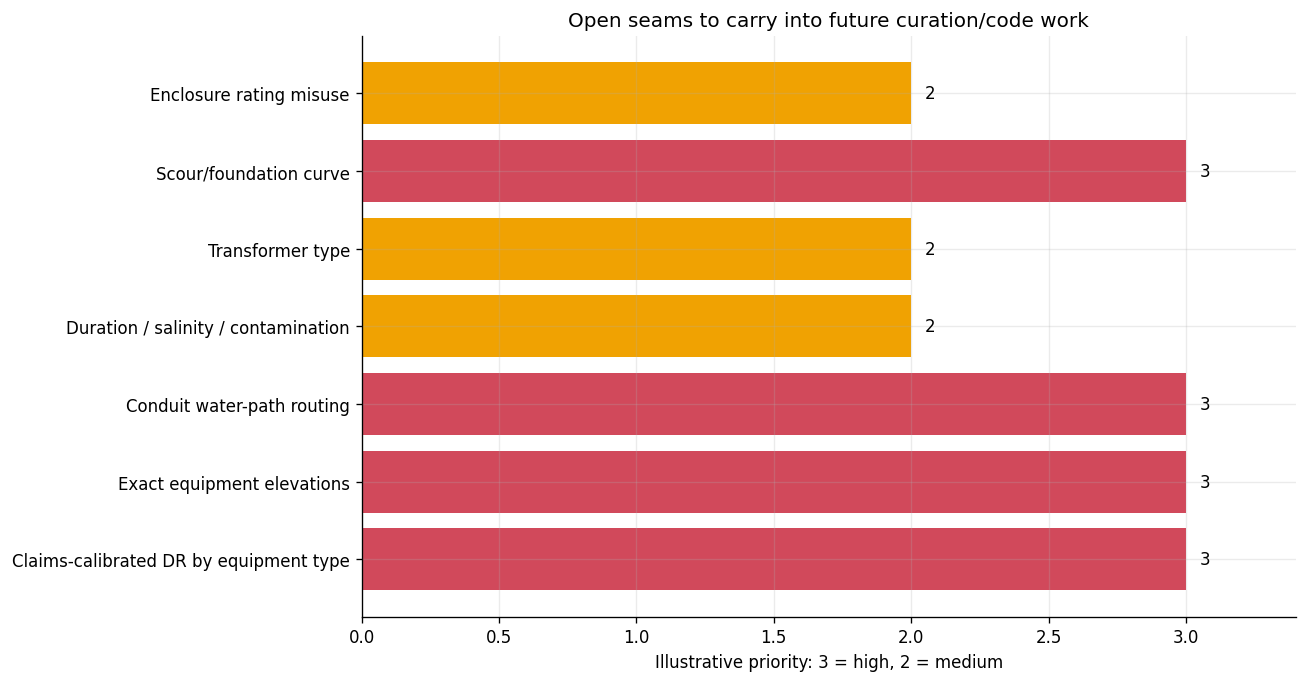

In [10]:
open_seams = pd.DataFrame([
    {"seam": "Claims-calibrated DR by equipment type", "why_it_matters": "v1.0 uses engineering parameters", "update_trigger": "insurer/claims/OEM/forensic dataset"},
    {"seam": "Exact equipment elevations", "why_it_matters": "local-depth transform controls DR", "update_trigger": "site survey / EPC drawings / digital twin"},
    {"seam": "Conduit water-path routing", "why_it_matters": "can damage elevated equipment", "update_trigger": "electrical one-line, civil grading, conduit layout"},
    {"seam": "Duration / salinity / contamination", "why_it_matters": "can shift reconditioning vs replacement", "update_trigger": "source with duration/contamination outcomes"},
    {"seam": "Transformer type", "why_it_matters": "dry-type vs liquid-filled changes replacement logic", "update_trigger": "asset metadata"},
    {"seam": "Scour/foundation curve", "why_it_matters": "site hydraulics/geotech dominate", "update_trigger": "hydraulic model or forensic scour dataset"},
    {"seam": "Enclosure rating misuse", "why_it_matters": "NEMA 4/4X is not submersion protection", "update_trigger": "actual rating/installation details"},
])
display(open_seams)

fig, ax = plt.subplots(figsize=(11, 5.8))
priority = [3, 3, 3, 2, 2, 3, 2]
ax.barh(open_seams["seam"], priority, color=["#d1495b" if p == 3 else "#f0a202" for p in priority])
ax.set_title("Open seams to carry into future curation/code work")
ax.set_xlabel("Illustrative priority: 3 = high, 2 = medium")
ax.set_xlim(0, 3.4)
for y, p in enumerate(priority):
    ax.text(p + 0.05, y, str(p), va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_open_seams_priority_view.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Capability Gate

The curation process ends with an honesty check: what can this artifact support today?

Current flood x solar capability:

- failure-unit scalar DR: supported;
- scenario loss with explicit value/exposure basis: supported;
- scalar EAL: conditional, requires downstream frequency layer and cap-binding preflight;
- PML/VaR/TVaR: withheld because no tail/spread distribution is carried.


In [11]:
cap = artifact["capability_declaration"]
display(pd.DataFrame([{"metric": k, "status": v} for k, v in cap["metrics_supportable"].items()]))
display(pd.DataFrame([{"field": k, "value": v} for k, v in cap["cap_binding"].items()]))

display(Markdown("**Derivation rationale serialized in artifact**"))
display(pd.DataFrame([{"field": k, "value": v} for k, v in artifact["derivation_rationale"].items()]))


,metric,status
0,failure_unit_scalar_dr,supported
1,scenario_loss_given_value_basis,supported_with_explicit_value_and_exposure_basis
2,scalar_eal,conditional_require_cap_binding_preflight
3,pml,withheld_no_tail_distribution
4,var,withheld_no_tail_distribution
5,tvar,withheld_no_tail_distribution


,field,value
0,policy,fail_closed
1,preflight_status,not_executed_no_downstream_frequency_or_state_distribution
2,required_before_scalar_eal,True
3,tolerance_pct,2.5
4,action_if_fail,require_mean_plus_spread_emit
5,reason,Current package contains severity curves but not downstream hazard/state distributions or project-specific cap tests.


**Derivation rationale serialized in artifact**

,field,value
0,source_spine,DOE/FEMP solar flood mechanisms plus NEMA water-damaged electrical-equipment replacement/evaluation framing.
1,form_reasoning,"Flood electrical damage is state/threshold-like by local component datum, so piecewise depth-percent curves are more auditable than logistics."
2,demoted_sources,"USACE depth-percent precedent supports tabular form, not solar values; scour and duration/salinity are carried as open seams."
3,tier_mix,Depth transform and mechanism are T2; numeric DR ordinates are mostly T3; foundation scour proxy is T4.


## 11. Reviewer Checklist For Explaining Flood x Solar

Use this when explaining the cell to someone else:

- Are we clear this is **not** a whole-plant flood curve?
- Did we compute local depth by component datum, not use a single site depth blindly?
- Are failure-unit value buckets explicit?
- Are selectors separated from conditioners and exposure multipliers?
- Are exact DR percentages labeled as engineering parameterization, not claims calibration?
- Is the foundation/scour proxy clearly labeled T4 placeholder?
- Are duration, salinity, contamination, conduit path, and enclosure-rating limitations visible?
- Are annual risk metrics withheld until Hazard supplies frequency, event sampling, value basis, and uncertainty treatment?

This is the main architectural lesson: flood makes the case for a modular damage-code discipline because the physics and value application are naturally component-specific.
